<a href="https://colab.research.google.com/github/abdelrahman-elhadik/Food_Recommendation_ML/blob/main/food%26Exerrcise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [2]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

## part 1 calorie

In [ ]:
!kaggle datasets download  -d  vechoo/diet-plan-recommendation

Dataset URL: https://www.kaggle.com/datasets/vechoo/diet-plan-recommendation
License(s): unknown
  0% 0.00/431k [00:00<?, ?B/s]
100% 431k/431k [00:00<00:00, 1.18GB/s]


In [ ]:
!unzip /content/diet-plan-recommendation.zip

Archive:  /content/diet-plan-recommendation.zip
  inflating: Dataset.csv             


In [ ]:
df = pd.read_csv("/content/Dataset.csv")
df.head(5)

,Unnamed: 0,age,weight(kg),height(m),gender,BMI,BMR,activity_level,calories_to_maintain_weight,BMI_tags,Label
0,1,2,16.097862,0.932025,F,18.531612,958.584,1.2,1150.3008,8,13
1,2,4,14.619374,0.916687,F,17.397496,932.383,1.7,1585.0511,7,1
2,4,4,17.899918,0.997288,F,17.997414,977.578,1.9,1857.3982,7,4
3,6,3,13.532880,1.022786,F,12.936609,944.689,1.9,1794.9091,7,3
4,8,4,17.039484,1.053977,M,15.338909,799.229,1.9,1518.5351,7,0


In [ ]:
df = df.drop(["Unnamed: 0", "BMI_tags", "Label"], axis=1)
df = pd.get_dummies(df, columns=['gender'], drop_first=False)

In [ ]:
X = df.drop(['calories_to_maintain_weight'], axis=1)
Y = df['calories_to_maintain_weight']

In [ ]:
print(X.head())
print(Y.head())

   age  weight(kg)  height(m)        BMI      BMR  activity_level  gender_F  \
0    2   16.097862   0.932025  18.531612  958.584             1.2      True   
1    4   14.619374   0.916687  17.397496  932.383             1.7      True   
2    4   17.899918   0.997288  17.997414  977.578             1.9      True   
3    3   13.532880   1.022786  12.936609  944.689             1.9      True   
4    4   17.039484   1.053977  15.338909  799.229             1.9     False   

   gender_M  
0     False  
1     False  
2     False  
3     False  
4      True  
0    1150.3008
1    1585.0511
2    1857.3982
3    1794.9091
4    1518.5351
Name: calories_to_maintain_weight, dtype: float64


In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)


In [ ]:
modelLR = LinearRegression()
modelLR.fit(X_train, Y_train)
Y_pred = modelLR.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = modelLR.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(Y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

# R² Score (Coefficient of Determination)
r2 = r2_score(Y_test, y_pred)
print(f"R² Score: {r2}")

# Model Accuracy (same as R² for regression)
accuracy = modelLR.score(X_test, Y_test)
print(f"Model Score (R²): {accuracy * 100:.2f}%")

Mean Squared Error (MSE): 1966.0291331480473
R² Score: 0.9874469425828112
Model Score (R²): 98.74%


In [ ]:
def calculate_bmi(weight_kg, height_m):
    return weight_kg / (height_m ** 2)

def calculate_bmr(age, weight_kg, height_m, gender_F, gender_M):
    if gender_F == 1:  # Female
        return 655 + (9.6 * weight_kg) + (1.8 * height_m * 100) - (4.7 * age)
    elif gender_M == 1:  # Male
        return 66 + (13.7 * weight_kg) + (5 * height_m * 100) - (6.8 * age)
    else:
        raise ValueError("Invalid gender values")

def calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval, modelLR):
    # Extract user inputs
    age = user_inputs['age']
    weight_kg = user_inputs['weight(kg)']
    height_m = user_inputs['height(m)']
    gender_F = user_inputs['gender_F']
    gender_M = user_inputs['gender_M']
    activity_level = user_inputs['activity_level']

    # Calculate BMI and BMR using the provided formulas
    BMI = calculate_bmi(weight_kg, height_m)
    BMR = calculate_bmr(age, weight_kg, height_m, gender_F, gender_M)

    # Calculate total weight change
    weight_change = desired_weight - initial_weight
    calories_per_kg = 7700

    daily_weight_change =(weight_change) / (time_interval)
    # Estimated calories per kg change (adjust as needed)


    # Calculate caloric difference based on weight change goal
    caloric_difference = daily_weight_change * calories_per_kg

    # Create input array for model prediction
    input_array = np.array([[age, weight_kg, height_m, BMI, BMR, activity_level, gender_F, gender_M]])

    # Use the trained model to predict daily maintenance calories
    model_predicted_calories = modelLR.predict(input_array)
    print(f"Estimated Daily Caloric Intake for Weight Maintenance : {model_predicted_calories[0]:.2f} calories")
    # Sum the model predicted calories and caloric difference
    daily_cal = model_predicted_calories + caloric_difference

    return daily_cal

In [ ]:
# Example usage
user_inputs = {
    'age': 25,
    'weight(kg)': 70,
    'height(m)': 1.75,
    'gender_F': 0,  # Female
    'gender_M': 1,  # Male
    'activity_level': 1.5  # Moderate activity level (replace with user input)
}

initial_weight = 100  # replace with user input
desired_weight = 80  # replace with user input
time_interval_days = 2000  # replace with user input

# Assume 'model' is your trained machine learning model
daily_calorie_difference_direct = calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval_days, modelLR)

# Display the result
print(f"Estimated Daily Caloric Intake for Weight Change: {daily_calorie_difference_direct[0]:.2f} calories")

Estimated Daily Caloric Intake for Weight Maintenance : 2546.67 calories
Estimated Daily Caloric Intake for Weight Change: 2469.67 calories


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##part2

In [ ]:
!kaggle datasets download  -d  vaishnavivenkatesan/food-and-their-calories

Dataset URL: https://www.kaggle.com/datasets/vaishnavivenkatesan/food-and-their-calories
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/6.59k [00:00<?, ?B/s]
100% 6.59k/6.59k [00:00<00:00, 15.1MB/s]


In [162]:
!kaggle datasets download  -d shuyangli94/food-com-recipes-and-user-interactions

Dataset URL: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions
License(s): copyright-authors
 90% 240M/267M [00:00<00:00, 542MB/s] 
100% 267M/267M [00:00<00:00, 541MB/s]


In [ ]:
!unzip /content/food-and-their-calories.zip

Archive:  /content/food-and-their-calories.zip
  inflating: Food and Calories - Sheet1.csv  


In [163]:
!unzip /content/food-com-recipes-and-user-interactions.zip

Archive:  /content/food-com-recipes-and-user-interactions.zip
  inflating: PP_recipes.csv          
  inflating: PP_users.csv            
  inflating: RAW_interactions.csv    
  inflating: RAW_recipes.csv         
  inflating: ingr_map.pkl            
  inflating: interactions_test.csv   
  inflating: interactions_train.csv  
  inflating: interactions_validation.csv  


In [ ]:
food_df = pd.read_csv('/content/RAW_recipes.csv')
food_df.head(5)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [ ]:
# Extract unique food names
unique_food_names = food_df['name'].unique()
# Print the total number of unique food names
total_unique_food_names = len(unique_food_names)
print("Total Unique Food Names:", total_unique_food_names)

# Print the top 100 unique food names
print("\nTop 100 Unique Food Names:")
for food_name in unique_food_names[:100]:
    print(food_name)

Total Unique Food Names: 230186

Top 100 Unique Food Names:
arriba   baked winter squash mexican style
a bit different  breakfast pizza
all in the kitchen  chili
alouette  potatoes
amish  tomato ketchup  for canning
apple a day  milk shake
aww  marinated olives
backyard style  barbecued ribs
bananas 4 ice cream  pie
beat this  banana bread
berry  good sandwich spread
better than sex  strawberries
better then bush s  baked beans
boat house  collard greens
calm your nerves  tonic
chicken lickin  good  pork chops
chile rellenos
chinese  candy
chinese  chop suey
cream  of cauliflower soup  vegan
cream  of spinach soup
cream  of spinach soup  vegan
crispy crunchy  chicken
deep fried dessert thingys
easiest ever  hollandaise sauce
emotional balance  spice mixture
fool the meat eaters  chili
forgotten  minestrone
fried  potatoes
george s at the cove  black bean soup
get the sensation  brownies
global gourmet  taco casserole
grilled  ranch bread
grilled  venison burgers
healthy for them  yogur

In [ ]:
# DIRECT K MEANS CLUSTERING APPROACH.
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

food_df = pd.read_csv('/content/RAW_recipes.csv')
def preprocess_data(df):
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']] = df['nutrition'].str.split(",", expand=True)
    df['calories'] = df['calories'].apply(lambda x: x.replace('[',''))
    df['carbohydrates (PDV)'] = df['carbohydrates (PDV)'].apply(lambda x: x.replace(']',''))
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']] = df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']].astype('float')

    df.drop(['id', 'contributor_id', 'submitted', 'tags', 'nutrition'], axis=1, inplace=True)


    df['food types'] = np.nan
    df['food types'] = df['food types'].astype('str')

    for i in df.index:
        if 'eggs' not in df.loc[i, 'ingredients']:
            if 'ice-cream' in df.loc[i, 'ingredients'] or 'chocolate' in df.loc[i, 'ingredients'] or 'cookies' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Veg dessert'
        elif 'eggs' in df.loc[i, 'ingredients']:
            if 'ice-cream' in df.loc[i, 'ingredients'] or 'chocolate' in df.loc[i, 'ingredients'] or 'cookies' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Non-Veg dessert'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and 20 < df.loc[i, 'calories'] < 300:
            df.loc[i, 'food types'] = 'Healthy'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and df.loc[i, 'food types'] != 'Healthy':
            if 'chicken' in df.loc[i, 'ingredients'] or 'eggs' in df.loc[i, 'ingredients'] or 'ham' in df.loc[i, 'ingredients'] or 'pepperoni' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Non-veg'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and df.loc[i, 'food types'] != 'Healthy' and df.loc[i, 'food types'] != 'Non-veg':
            df.loc[i, 'food types'] = 'Veg'

    df['food types'].value_counts()
    df['food types'].isnull().sum()

    return df

# Apply the function to your dataframe
food_df = preprocess_data(food_df)
food_df.head()

# One-hot encode food types
types = pd.get_dummies(food_df['food types'])
food_df = pd.concat([food_df, types], axis=1)

# Create a pivot table for nutrient details
cal = food_df.pivot_table(columns='name', values=['total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'])

# Apply K-Means clustering
columns_for_clustering = ['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']
clustering_data = food_df[columns_for_clustering]
scaler = StandardScaler()
clustering_data_standardized = scaler.fit_transform(clustering_data)

kmeans = KMeans(n_clusters=2000, n_init=10, random_state=42)
food_df['cluster'] = kmeans.fit_predict(clustering_data_standardized)
print(food_df.head(5))

                                         name  minutes  n_steps  \
0  arriba   baked winter squash mexican style       55       11   
1            a bit different  breakfast pizza       30        9   
2                   all in the kitchen  chili      130        6   
3                          alouette  potatoes       45       11   
4          amish  tomato ketchup  for canning      190        5   

                                               steps  \
0  ['make a choice and proceed with recipe', 'dep...   
1  ['preheat oven to 425 degrees f', 'press dough...   
2  ['brown ground beef in large pot', 'add choppe...   
3  ['place potatoes in a large pot of lightly sal...   
4  ['mix all ingredients& boil for 2 1 / 2 hours ...   

                                         description  \
0  autumn is my favorite time of year to cook! th...   
1  this recipe calls for the crust to be prebaked...   
2  this modified version of 'mom's' chili was a h...   
3  this is a super easy, great tasti

In [ ]:
cluster_counts = food_df['cluster'].value_counts()

# Display the number of elements in each cluster
print("Number of elements in each cluster:")
print(cluster_counts.head(50))

Number of elements in each cluster:
cluster
930     4757
154     3013
1529    2643
800     2553
1958    2396
1859    2202
80      2096
1652    2088
1855    1972
1531    1761
1409    1702
646     1685
376     1606
1473    1598
578     1553
739     1471
1687    1435
811     1422
275     1392
1125    1378
606     1322
1312    1302
529     1247
146     1244
375     1171
834     1166
441     1136
1259    1117
464     1110
1561    1088
1725    1072
1653    1046
1745    1009
1777     997
93       987
1916     967
554      964
905      959
1517     947
14       929
528      928
1901     917
360      915
1931     911
807      871
889      850
49       847
729      843
514      840
1609     826
Name: count, dtype: int64


In [ ]:
# Plot Pie Chart Function
# -----------------------------
def plot_pie_chart(ax, data, labels):
    ax.pie(data, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=['#99ff99', '#ffcc99', '#ccffcc', '#ff6666', '#c2f0c2'])
    ax.axis('equal')
    ax.set_facecolor('#1a1a1a')

In [ ]:
# -----------------------------
# Find Closest Food Function
# -----------------------------
def find_closest_food(target_food, target_features, exclude_foods=[]):
    recommended_items = []

    target_cluster_df = food_df.loc[food_df['name'] == target_food, 'cluster']
    if target_cluster_df.empty:
        return recommended_items

    target_cluster = target_cluster_df.values[0]

    cluster_recipes = food_df[food_df['cluster'] == target_cluster]
    cluster_recipes = cluster_recipes[~cluster_recipes['name'].isin(exclude_foods)]

    if cluster_recipes.empty:
        return recommended_items

    # 🔥 التحويل المهم
    cluster_values = cluster_recipes[columns_for_clustering].values.astype(float)
    target_values = target_features.astype(float).reshape(1, -1)

    distances = np.linalg.norm(cluster_values - target_values, axis=1)

    cluster_recipes = cluster_recipes.copy()
    cluster_recipes['distance_to_target'] = distances

    closest_recipes = cluster_recipes.sort_values('distance_to_target').head(5)
    recommended_items.append(closest_recipes)

    return recommended_items

In [ ]:
# -----------------------------
# Meal Time Rules
# -----------------------------
meal_time_rules = {
    'Breakfast': {'protein_min':15, 'calories_max':500, 'fat_max':15},
    'Mid_Morning_Snack': {'calories_max':300},
    'Lunch': {'protein_min':20, 'calories_min':500, 'calories_max':800},
    'Evening_Snack': {'calories_max':300},
    'Dinner': {'calories_max':600, 'carbs_max':40}
}

def pick_meal_by_time(meal_time):
    rules = meal_time_rules[meal_time]
    df = food_df.copy()
    # Filter by meal time rules
    if 'protein_min' in rules:
        df = df[df['protein (PDV)'] >= rules['protein_min']]
    if 'calories_min' in rules:
        df = df[df['calories'] >= rules['calories_min']]
    if 'calories_max' in rules:
        df = df[df['calories'] <= rules['calories_max']]
    if 'fat_max' in rules:
        df = df[df['total fat (PDV)'] <= rules['fat_max']]
    if 'carbs_max' in rules:
        df = df[df['carbohydrates (PDV)'] <= rules['carbs_max']]

    if df.empty:
        return None
    return df.sample(1).iloc[0]


🍽 Breakfast
Recommended: basil rice soup  minestra di riso e basilico | Calories: 189.8


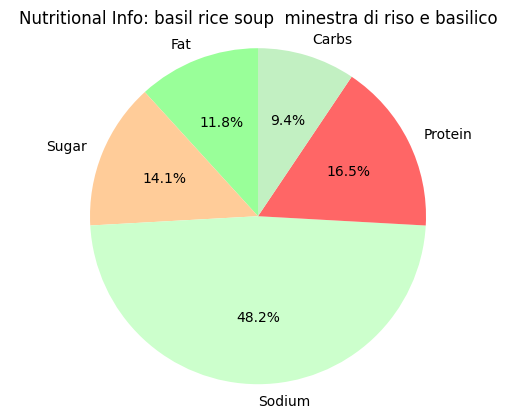


🍽 Mid_Morning_Snack
Recommended: cinnamon sticks | Calories: 45.9


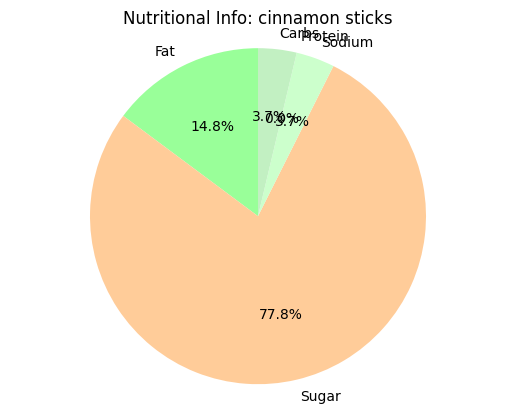


🍽 Lunch
Recommended: roasted red bell pepper hummus | Calories: 699.6


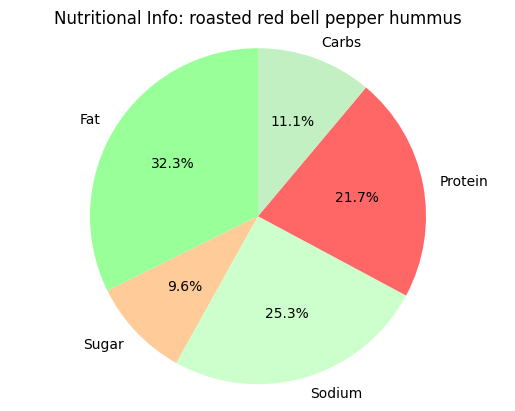


🍽 Evening_Snack
Recommended: authentic salade nicoise | Calories: 151.9


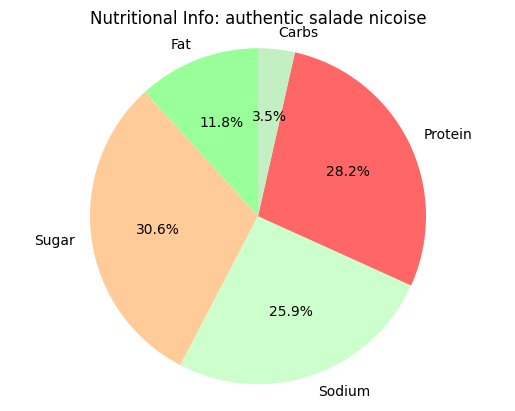


🍽 Dinner
Recommended: moroccan white beans loubia | Calories: 468.9


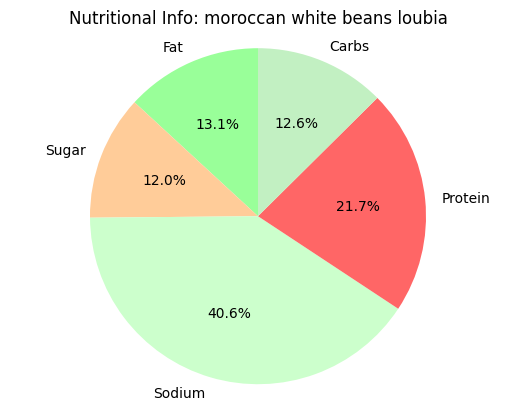

In [ ]:
# -----------------------------
# Generate Recommendations
# -----------------------------
meal_times = ['Breakfast', 'Mid_Morning_Snack', 'Lunch', 'Evening_Snack', 'Dinner']
selected_foods = []
lose_weight = 1

for meal_time in meal_times:
    print(f"\n🍽 {meal_time}")

    picked_food = pick_meal_by_time(meal_time)
    if picked_food is None:
        print("No suitable food found")
        continue

    target_food = picked_food['name']
    target_features = picked_food[columns_for_clustering].values
    recommendations = find_closest_food(target_food, target_features, exclude_foods=selected_foods)

    if not recommendations:
        print("No recommendations found")
        continue

    selected_foods.extend(recommendations[0]['name'].tolist())

    # Choose best recommendation
    if lose_weight:
        best = recommendations[0].sort_values('calories').head(1)
    else:
        best = recommendations[0].sort_values('calories', ascending=False).head(1)

    for _, row in best.iterrows():
        print(f"Recommended: {row['name']} | Calories: {row['calories']}")

        fig, ax = plt.subplots()
        nutritional_data = [
            row['total fat (PDV)'], row['sugar (PDV)'], row['sodium (PDV)'],
            row['protein (PDV)'], row['carbohydrates (PDV)']
        ]
        labels = ['Fat', 'Sugar', 'Sodium', 'Protein', 'Carbs']
        plot_pie_chart(ax, nutritional_data, labels)
        plt.title(f"Nutritional Info: {row['name']}")
        plt.show()

## Meal plan for week or month

In [ ]:
import pandas as pd

meal_times = ['Breakfast', 'Mid_Morning_Snack', 'Lunch', 'Evening_Snack', 'Dinner']

def generate_meal_plan(
    days=7,
    calorie_limit=2000,
    lose_weight=True,
    min_days_before_repeat=3
):
    meal_plan = {}
    food_history = {}  # food_name -> last_day_used

    for day in range(1, days + 1):
        print(f"\n📅 Day {day}")
        daily_plan = {}
        daily_calories = 0

        for meal_time in meal_times:
            picked_food = pick_meal_by_time(meal_time)
            if picked_food is None:
                continue

            target_features = picked_food[columns_for_clustering].values

            recommendations = find_closest_food(
                picked_food['name'],
                target_features,
                exclude_foods=list(food_history.keys())
            )

            if not recommendations:
                continue

            # ترتيب حسب الهدف
            if lose_weight:
                candidates = recommendations[0].sort_values('calories')
            else:
                candidates = recommendations[0].sort_values('calories', ascending=False)

            selected = None

            for _, row in candidates.iterrows():
                food_name = row['name']
                food_cal = row['calories']

                # ✅ Calories Control
                if daily_calories + food_cal > calorie_limit:
                    continue

                # ✅ Prevent repetition
                last_used = food_history.get(food_name, -100)
                if day - last_used < min_days_before_repeat:
                    continue

                selected = row
                break

            if selected is None:
                continue

            daily_plan[meal_time] = {
                "name": selected['name'],
                "calories": selected['calories']
            }

            daily_calories += selected['calories']
            food_history[selected['name']] = day

            print(f"🍽 {meal_time}: {selected['name']} ({selected['calories']} cal)")

        daily_plan["Total_Calories"] = daily_calories
        meal_plan[f"Day {day}"] = daily_plan

        print(f"🔥 Total Calories: {daily_calories}")

    return meal_plan

In [ ]:
weekly_plan = generate_meal_plan(
    days=7,
    calorie_limit=1800,
    lose_weight=True
)


📅 Day 1
🍽 Breakfast: baked hoisin chicken buns (266.7 cal)
🍽 Mid_Morning_Snack: portabella mushroom salad (278.6 cal)
🍽 Lunch: kashmiri chicken  cardamom and saffron pilau  spiced indian rice (680.9 cal)
🍽 Evening_Snack: chicken marengo with mushrooms (199.6 cal)
🍽 Dinner: italian spaghetti with meatballs (306.7 cal)
🔥 Total Calories: 1732.4999999999998

📅 Day 2
🍽 Breakfast: crusty parmesan flounder fillets (165.8 cal)
🍽 Mid_Morning_Snack: truvia classic cheesecake (285.9 cal)
🍽 Lunch: red cabbage millet gratin  german vegetarian (534.1 cal)
🍽 Evening_Snack: tuna topped chopped salad to go (208.1 cal)
🍽 Dinner: lamb shoulder bake with dried apricots (117.2 cal)
🔥 Total Calories: 1311.1

📅 Day 3
🍽 Breakfast: tropical crock pot chicken (273.2 cal)
🍽 Mid_Morning_Snack: fish fillets with mushroom lemon sauce (234.0 cal)
🍽 Lunch: creamy augratin potatoes  crockpot (515.2 cal)
🍽 Evening_Snack: cream cheese oyster roll (123.4 cal)
🍽 Dinner: amazing basil chicken   low fat (153.1 cal)
🔥 Total

In [ ]:
monthly_plan = generate_meal_plan(
    days=30,
    calorie_limit=2200,
    lose_weight=False
)


📅 Day 1
🍽 Breakfast: sauteed shrimp parmesan (75.5 cal)
🍽 Mid_Morning_Snack: longhorn s prairie dust (5.8 cal)
🍽 Lunch: garlic sausage penne bake (691.0 cal)
🍽 Evening_Snack: shortbread crust for custard tart (173.9 cal)
🍽 Dinner: lemon glazed carrots and rutabagas (90.6 cal)
🔥 Total Calories: 1036.8

📅 Day 2
🍽 Breakfast: south beach marinated flank steak (196.8 cal)
🍽 Mid_Morning_Snack: puree of butternut squash soup (143.2 cal)
🍽 Lunch: st patrick s pie (738.2 cal)
🍽 Evening_Snack: cherry gelatin squares (162.5 cal)
🍽 Dinner: white chicken chili  simple (491.9 cal)
🔥 Total Calories: 1732.6

📅 Day 3
🍽 Breakfast: turkey bratwurst patties (171.3 cal)
🍽 Mid_Morning_Snack: chocolate pepper cookies  south african (142.5 cal)
🍽 Lunch: roasted teriyaki tofu steaks with glazed green vegetables (526.2 cal)
🍽 Evening_Snack: peanut butter cheerios treats (214.0 cal)
🍽 Dinner: caribbean pork roast (155.3 cal)
🔥 Total Calories: 1209.3

📅 Day 4
🍽 Breakfast: scallion chicken and soba noodles  ww (2

## live plan


In [ ]:

user_inputs = {
    'age': 25,
    'weight(kg)': 55,
    'height(m)': 1.75,
    'gender_F': 0,  # Female
    'gender_M': 1,  # Male
    'activity_level': 1.5  # Moderate activity level (replace with user input)

}

initial_weight = 100  # replace with user input
desired_weight = 90  # replace with user input
time_interval_days = 60  # replace with user input

# بعد حساب daily_calorie_difference_direct
if desired_weight < initial_weight:
    user_inputs['goal'] = 'lose_weight'
else:
    user_inputs['goal'] = 'gain_weight'

# Assume 'model' is your trained machine learning model
daily_calorie_difference_direct = calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval_days, modelLR)

# Display the result
print(f"Estimated Daily Caloric Intake for Weight Change: {daily_calorie_difference_direct[0]:.2f} calories")

Estimated Daily Caloric Intake for Weight Maintenance : 2294.21 calories
Estimated Daily Caloric Intake for Weight Change: 1010.88 calories


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
weekly_plan = generate_meal_plan(
    days=time_interval_days,
    calorie_limit=daily_calorie_difference_direct[0],
    lose_weight = True if user_inputs['goal'] == 'lose_weight' else False

)


📅 Day 1
🍽 Breakfast: split pea soup with ham and vegetables (365.4 cal)
🍽 Mid_Morning_Snack: creamy grape salad (256.6 cal)
🍽 Evening_Snack: bleu cheese stuffed mushrooms (59.5 cal)
🔥 Total Calories: 681.5

📅 Day 2
🍽 Breakfast: cold yogurt soup (265.3 cal)
🍽 Mid_Morning_Snack: seared lemon chicken (205.3 cal)
🍽 Evening_Snack: cucumber party bread (65.1 cal)
🍽 Dinner: strudel sticks (219.4 cal)
🔥 Total Calories: 755.1

📅 Day 3
🍽 Breakfast: creamy swiss chard and pasta (248.1 cal)
🍽 Mid_Morning_Snack: oriental asparagus (48.0 cal)
🍽 Lunch: red bean chili (547.6 cal)
🍽 Evening_Snack: crab salad english muffin melt (121.6 cal)
🔥 Total Calories: 965.3000000000001

📅 Day 4
🍽 Breakfast: grilled copper river cod (261.3 cal)
🍽 Mid_Morning_Snack: spicy spinach artichoke dip (159.0 cal)
🍽 Lunch: betty givan s parmesan chicken casserole with wild rice (573.4 cal)
🔥 Total Calories: 993.7

📅 Day 5
🍽 Breakfast: blueberry oat bran (350.0 cal)
🍽 Mid_Morning_Snack: thai banana and green chilli salad (2

##save

In [ ]:
import joblib
import os

models_dir = "saved_models"
os.makedirs(models_dir, exist_ok=True)

# Save Linear Regression (calories prediction)
joblib.dump(modelLR, f"{models_dir}/calorie_model.pkl")

# Save KMeans + Scaler
joblib.dump(kmeans, f"{models_dir}/kmeans.pkl")
joblib.dump(scaler, f"{models_dir}/scaler.pkl")

# Save feature names
joblib.dump(X_train.columns.tolist(), f"{models_dir}/feature_names.pkl")

print("✅ Models saved successfully")

## deployment

In [220]:
!pip install -q streamlit pyngrok joblib scikit-learn pandas numpy

In [221]:
#!ngrok config add-authtoken 2zxQfcMZchS7mcex4Qdb8nhM0yu_5nhBWVooR8wq799NFoeq7
!ngrok config add-authtoken 3AU11KAVBENX7AHaRPso159FJoD_52WSPZqFy372zJM3YnqoD


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [206]:
import pandas as pd
food_df = pd.read_csv("/content/saved_models/RAW_recipes.csv")
food_df.head()

,,,,chicken breasts','ground ginger','pepper','honey','bisquick','seasoning salt',"'vegetable oil']""",7
home style creamed corn casserole,50675,30,56266,2003-01-10,"['30-minutes-or-less', 'time-to-make', 'main-i...","[188.3, 2.0, 21.0, 27.0, 10.0, 1.0, 14.0]",5,"['combine all ingredients in a large bowl', 'm...",this is a tasty comfort food. very easy to pre...,"['cream-style corn', 'minute rice', 'egg', 'sa...",5
home style pasta italiano,283583,30,380466,2008-02-02,"['30-minutes-or-less', 'time-to-make', 'course...","[1034.1, 73.0, 84.0, 90.0, 80.0, 66.0, 36.0]",7,"['cook sausage per above directions', 'cook th...",this was on the back of the italian sausage pa...,"['italian sausages', 'rigatoni pasta', 'olive ...",7
home style potatoes,164199,40,73836,2006-04-13,"['course', 'main-ingredient', 'side-dishes', '...","[76.9, 3.0, 2.0, 0.0, 3.0, 1.0, 4.0]",5,"['pre-heat the oven to 425f', 'mix the potatoe...",we love these spicy potatoes. easily done and...,"['new potatoes', 'olive oil', 'water', 'paprik...",9
home style scalloped potatoes,80989,75,39547,2004-01-13,"['time-to-make', 'course', 'main-ingredient', ...","[267.9, 19.0, 4.0, 21.0, 15.0, 40.0, 10.0]",11,"['in a large saucepan , saut onion in butter u...","nothing fancy here - just good, old fashioned ...","['onion', 'butter', 'all-purpose flour', 'salt...",7
home style white for the bread machine,55553,130,8688,2003-03-04,"['weeknight', 'time-to-make', 'course', 'prepa...","[1576.5, 67.0, 185.0, 112.0, 81.0, 127.0, 84.0]",8,"[""combine all ingredients according to your ma...","this is a bread like grandma used to make, ric...","['water', 'white bread flour', 'dry milk', 'sa...",8


In [245]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# ---------------------------
# Load Models & Data
# ---------------------------
modelLR = joblib.load('saved_models/calorie_model.pkl')
kmeans = joblib.load('saved_models/kmeans.pkl')
scaler = joblib.load('saved_models/scaler.pkl')
feature_names = joblib.load('saved_models/feature_names.pkl')

food_df = pd.read_csv('/content/RAW_recipes.csv')  # ضع مسار ملفك هنا

# ---------------------------
# Preprocessing Function
# ---------------------------
def preprocess_data(df):
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)',
        'saturated fat (PDV)', 'carbohydrates (PDV)']] = df['nutrition'].str.split(",", expand=True)
    df['calories'] = df['calories'].str.replace('[','').astype(float)
    df['carbohydrates (PDV)'] = df['carbohydrates (PDV)'].str.replace(']','').astype(float)
    df[['total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)']] = \
        df[['total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)']].astype(float)

    df.drop(['id', 'contributor_id', 'submitted', 'tags', 'nutrition'], axis=1, inplace=True)

    # Assign food types
    df['food types'] = 'Veg'
    for i in df.index:
        if 'eggs' in df.loc[i,'ingredients']:
            df.loc[i,'food types']='Non-Veg'
        if any(x in df.loc[i,'ingredients'] for x in ['ice-cream','chocolate','cookies']):
            df.loc[i,'food types']='Veg dessert' if 'eggs' not in df.loc[i,'ingredients'] else 'Non-Veg dessert'
        if 20 < df.loc[i,'calories'] < 300 and df.loc[i,'food types'] not in ['Veg dessert','Non-Veg dessert']:
            df.loc[i,'food types']='Healthy'

    return df

food_df = preprocess_data(food_df)

columns_for_clustering = [
    'calories', 'total fat (PDV)', 'sugar (PDV)',
    'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'
]

# ---------------------------
# Helper Functions
# ---------------------------
def find_closest_food(target_food, target_features, exclude_foods=[]):
    recommended_items = []
    if 'cluster' not in food_df.columns:
        # لو الـ cluster مش معمول قبل كده، نعمله دلوقتي
        clustering_data = food_df[columns_for_clustering].values
        clustering_data_standardized = scaler.transform(clustering_data)
        food_df['cluster'] = kmeans.predict(clustering_data_standardized)

    target_cluster_df = food_df.loc[food_df['name'] == target_food, 'cluster']
    if target_cluster_df.empty:
        return recommended_items
    target_cluster = target_cluster_df.values[0]
    cluster_recipes = food_df[food_df['cluster'] == target_cluster]
    cluster_recipes = cluster_recipes[~cluster_recipes['name'].isin(exclude_foods)]
    if cluster_recipes.empty:
        return recommended_items
    cluster_values = cluster_recipes[columns_for_clustering].values.astype(float)
    target_values = target_features.astype(float).reshape(1, -1)
    distances = np.linalg.norm(cluster_values - target_values, axis=1)
    cluster_recipes = cluster_recipes.copy()
    cluster_recipes['distance_to_target'] = distances
    closest_recipes = cluster_recipes.sort_values('distance_to_target').head(5)
    recommended_items.append(closest_recipes)
    return recommended_items

meal_time_rules = {
    'Breakfast': {'protein_min':15, 'calories_max':500, 'fat_max':15},
    'Mid_Morning_Snack': {'calories_max':300},
    'Lunch': {'protein_min':20, 'calories_min':500, 'calories_max':800},
    'Evening_Snack': {'calories_max':300},
    'Dinner': {'calories_max':600, 'carbs_max':40}
}

def pick_meal_by_time(meal_time):
    rules = meal_time_rules[meal_time]
    df = food_df.copy()
    if 'protein_min' in rules:
        df = df[df['protein (PDV)'] >= rules['protein_min']]
    if 'calories_min' in rules:
        df = df[df['calories'] >= rules['calories_min']]
    if 'calories_max' in rules:
        df = df[df['calories'] <= rules['calories_max']]
    if 'fat_max' in rules:
        df = df[df['total fat (PDV)'] <= rules['fat_max']]
    if 'carbs_max' in rules:
        df = df[df['carbohydrates (PDV)'] <= rules['carbs_max']]
    if df.empty:
        return None
    return df.sample(1).iloc[0]

def generate_meal_plan(days=7, calorie_limit=2000, lose_weight=True):
    meal_times = ['Breakfast', 'Mid_Morning_Snack', 'Lunch', 'Evening_Snack', 'Dinner']
    meal_plan = {}
    food_history = {}
    for day in range(1, days+1):
        daily_plan = {}
        daily_calories = 0
        for meal_time in meal_times:
            picked_food = pick_meal_by_time(meal_time)
            if picked_food is None:
                continue
            target_features = picked_food[columns_for_clustering].values
            recommendations = find_closest_food(picked_food['name'], target_features, exclude_foods=list(food_history.keys()))
            if not recommendations:
                continue
            if lose_weight:
                candidates = recommendations[0].sort_values('calories')
            else:
                candidates = recommendations[0].sort_values('calories', ascending=False)
            selected = None
            for _, row in candidates.iterrows():
                food_name = row['name']
                food_cal = row['calories']
                if daily_calories + food_cal > calorie_limit:
                    continue
                last_used = food_history.get(food_name, -100)
                if day - last_used < 3:
                    continue
                selected = row
                break
            if selected is None:
                continue
            daily_plan[meal_time] = {"name": selected['name'], "calories": selected['calories']}
            daily_calories += selected['calories']
            food_history[selected['name']] = day
        daily_plan["Total_Calories"] = daily_calories
        meal_plan[f"Day {day}"] = daily_plan
    return meal_plan

def calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, days, model):
    X = pd.DataFrame(columns=feature_names)
    for col in feature_names:
        val = user_inputs.get(col, 0)
        if isinstance(val, str):
            val = 0
        X.at[0, col] = val
    X = X.astype(float)
    daily_cal = modelLR.predict(X)[0]
    daily_cal = max(daily_cal, 1200)
    return daily_cal

# ---------------------------
# Example Inputs
# ---------------------------
user_inputs = {
     'age': 25,
    'weight(kg)': 70,
    'height(m)': 1.75,
    'gender_F': 0,  # Female
    'gender_M': 1,  # Male
    'activity_level': 1.5
}
initial_weight = 100
desired_weight = 90
time_interval_days = 7

if desired_weight < initial_weight:
    user_inputs['goal'] = 'lose_weight'
    lose_weight = True
else:
    user_inputs['goal'] = 'gain_weight'
    lose_weight = False

# ---------------------------
# Run Calculation
# ---------------------------
daily_cal = calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval_days, modelLR)
daily_cal = max(daily_cal, 1200)  # أقل حد منطقي للسعرات اليومية
print(f"Estimated Daily Caloric Intake: {daily_cal:.2f} kcal")

meal_plan = generate_meal_plan(days=time_interval_days, calorie_limit=daily_cal, lose_weight=lose_weight)

# ---------------------------
# Print Meal Plan
# ---------------------------
for day, meals in meal_plan.items():
    print(f"\n{day}")
    for meal_time, info in meals.items():
        if meal_time == "Total_Calories":
            print(f"Total Calories: {info:.2f}")
        else:
            print(f"{meal_time}: {info['name']} ({info['calories']:.2f} cal)")

Estimated Daily Caloric Intake: 1200.00 kcal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Day 1
Breakfast: easy crock pot pork tenderloin roast (279.80 cal)
Mid_Morning_Snack: crispy eggplant with spicy tomato feta cheese sauce (280.30 cal)
Lunch: onion caramelized potatoes (544.60 cal)
Total Calories: 1104.70

Day 2
Breakfast: oil free four bean salad (226.20 cal)
Mid_Morning_Snack: turkey meatballs in wine sauce (204.60 cal)
Lunch: simple french toast bake (755.40 cal)
Total Calories: 1186.20

Day 3
Breakfast: chicken  or mushroom or tofu  tortellini filling (133.30 cal)
Mid_Morning_Snack: gramma s tomato pie  lighter version (96.50 cal)
Lunch: korean inspired popcorn chicken (699.10 cal)
Evening_Snack: lazy day sweet sour chicken (83.60 cal)
Dinner: gravin chicken (111.70 cal)
Total Calories: 1124.20

Day 4
Breakfast: sweet and spicy garden relish  chow chow (335.00 cal)
Mid_Morning_Snack: company  green beans (135.20 cal)
Lunch: prosciutto  brie and apple panini with scallion butter (504.30 cal)
Evening_Snack: crock pot strawberry dump cake (150.00 cal)
Total Calories:

In [254]:
app_code = '''

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ---------------------------
# Load Models & Data
# ---------------------------
modelLR = joblib.load('saved_models/calorie_model.pkl')
kmeans = joblib.load('saved_models/kmeans.pkl')
scaler = joblib.load('saved_models/scaler.pkl')
feature_names = joblib.load('saved_models/feature_names.pkl')

food_df = pd.read_csv('/content/RAW_recipes.csv')  # ضع مسار ملفك هنا

# ---------------------------
# Preprocessing
# ---------------------------
def preprocess_data(df):
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)',
        'saturated fat (PDV)', 'carbohydrates (PDV)']] = df['nutrition'].str.split(",", expand=True)
    df['calories'] = df['calories'].str.replace('[','').astype(float)
    df['carbohydrates (PDV)'] = df['carbohydrates (PDV)'].str.replace(']','').astype(float)
    df[['total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)']] = \
        df[['total fat (PDV)','sugar (PDV)','sodium (PDV)','protein (PDV)','saturated fat (PDV)']].astype(float)
    df.drop(['id', 'contributor_id', 'submitted', 'tags', 'nutrition'], axis=1, inplace=True)

    df['food types'] = 'Veg'
    for i in df.index:
        if 'eggs' in df.loc[i,'ingredients']:
            df.loc[i,'food types']='Non-Veg'
        if any(x in df.loc[i,'ingredients'] for x in ['ice-cream','chocolate','cookies']):
            df.loc[i,'food types']='Veg dessert' if 'eggs' not in df.loc[i,'ingredients'] else 'Non-Veg dessert'
        if 20 < df.loc[i,'calories'] < 300 and df.loc[i,'food types'] not in ['Veg dessert','Non-Veg dessert']:
            df.loc[i,'food types']='Healthy'
    return df

food_df = preprocess_data(food_df)
columns_for_clustering = ['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)',
                          'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']

# ---------------------------
# Helper Functions
# ---------------------------
def find_closest_food(target_food, target_features, exclude_foods=[]):
    recommended_items = []
    if 'cluster' not in food_df.columns:
        clustering_data = food_df[columns_for_clustering].values
        clustering_data_standardized = scaler.transform(clustering_data)
        food_df['cluster'] = kmeans.predict(clustering_data_standardized)
    target_cluster_df = food_df.loc[food_df['name'] == target_food, 'cluster']
    if target_cluster_df.empty:
        return recommended_items
    target_cluster = target_cluster_df.values[0]
    cluster_recipes = food_df[food_df['cluster'] == target_cluster]
    cluster_recipes = cluster_recipes[~cluster_recipes['name'].isin(exclude_foods)]
    if cluster_recipes.empty:
        return recommended_items
    cluster_values = cluster_recipes[columns_for_clustering].values.astype(float)
    target_values = target_features.astype(float).reshape(1, -1)
    distances = np.linalg.norm(cluster_values - target_values, axis=1)
    cluster_recipes = cluster_recipes.copy()
    cluster_recipes['distance_to_target'] = distances
    closest_recipes = cluster_recipes.sort_values('distance_to_target').head(5)
    recommended_items.append(closest_recipes)
    return recommended_items

meal_time_rules = {
    'Breakfast': {'protein_min':15, 'calories_max':500, 'fat_max':15},
    'Mid_Morning_Snack': {'calories_max':300},
    'Lunch': {'protein_min':20, 'calories_min':500, 'calories_max':800},
    'Evening_Snack': {'calories_max':300},
    'Dinner': {'calories_max':600, 'carbs_max':40}
}

def pick_meal_by_time(meal_time):
    rules = meal_time_rules[meal_time]
    df = food_df.copy()
    if 'protein_min' in rules:
        df = df[df['protein (PDV)'] >= rules['protein_min']]
    if 'calories_min' in rules:
        df = df[df['calories'] >= rules['calories_min']]
    if 'calories_max' in rules:
        df = df[df['calories'] <= rules['calories_max']]
    if 'fat_max' in rules:
        df = df[df['total fat (PDV)'] <= rules['fat_max']]
    if 'carbs_max' in rules:
        df = df[df['carbohydrates (PDV)'] <= rules['carbs_max']]
    if df.empty:
        return None
    return df.sample(1).iloc[0]

def generate_meal_plan(days=7, calorie_limit=2000, lose_weight=True):
    meal_times = ['Breakfast', 'Mid_Morning_Snack', 'Lunch', 'Evening_Snack', 'Dinner']
    meal_plan = {}
    food_history = {}
    for day in range(1, days+1):
        daily_plan = {}
        daily_calories = 0
        for meal_time in meal_times:
            picked_food = pick_meal_by_time(meal_time)
            if picked_food is None:
                continue
            target_features = picked_food[columns_for_clustering].values
            recommendations = find_closest_food(picked_food['name'], target_features, exclude_foods=list(food_history.keys()))
            if not recommendations:
                continue
            candidates = recommendations[0].sort_values('calories') if lose_weight else recommendations[0].sort_values('calories', ascending=False)
            selected = None
            for _, row in candidates.iterrows():
                food_name = row['name']
                food_cal = row['calories']
                if daily_calories + food_cal > calorie_limit:
                    continue
                last_used = food_history.get(food_name, -100)
                if day - last_used < 3:
                    continue
                selected = row
                break
            if selected is None:
                continue
            daily_plan[meal_time] = {"name": selected['name'], "calories": selected['calories']}
            daily_calories += selected['calories']
            food_history[selected['name']] = day
        daily_plan["Total_Calories"] = daily_calories
        meal_plan[f"Day {day}"] = daily_plan
    return meal_plan

def calculate_daily_calories_direct(user_inputs, model):
    X = pd.DataFrame(columns=feature_names)
    for col in feature_names:
        val = user_inputs.get(col, 0)
        if isinstance(val, str):
            val = 0
        X.at[0, col] = val
    X = X.astype(float)
    daily_cal = model.predict(X)[0]
    return max(daily_cal, 1200)  # Minimum safe calories

# ---------------------------
# Streamlit App
# ---------------------------
st.title("🍽 Personalized Meal Planner")

age = st.number_input("Age", min_value=10, max_value=100, value=25)
weight = st.number_input("Weight (kg)", min_value=30, max_value=200, value=70)
height = st.number_input("Height (cm)", min_value=100, max_value=220, value=175)
gender = st.radio("Gender", ["Male", "Female"])
activity_level = st.slider("Activity Level", min_value=1.0, max_value=2.5, value=1.5, step=0.1)
desired_weight = st.number_input("Desired Weight (kg)", min_value=30, max_value=200, value=60)
days = st.number_input("Days for Meal Plan", min_value=1, max_value=30, value=7)

initial_weight = weight
lose_weight = desired_weight < initial_weight

if st.button("Generate Meal Plan"):
    user_inputs = {
        'age': age,
        'weight(kg)': weight,
        'height(m)': height / 100,  # convert cm to meters
        'gender_F': int(gender=="Female"),
        'gender_M': int(gender=="Male"),
        'activity_level': activity_level,
        'goal': 'lose_weight' if lose_weight else 'gain_weight'
    }

    daily_cal = calculate_daily_calories_direct(user_inputs, modelLR)
    st.write(f"**Estimated Daily Caloric Intake:** {daily_cal:.2f} kcal")

    meal_plan = generate_meal_plan(days=days, calorie_limit=daily_cal, lose_weight=lose_weight)

    for day, meals in meal_plan.items():
        st.subheader(day)
        for meal_time, info in meals.items():
            if meal_time=="Total_Calories":
                st.write(f"**Total Calories:** {info:.2f}")
            else:
                st.write(f"{meal_time}: {info['name']} ({info['calories']:.2f} cal)")

'''

with open("app1.py","w") as f:
    f.write(app_code)

print("✅ Streamlit app saved successfully as app.py")

✅ Streamlit app saved successfully as app.py


In [222]:
!pip install -q pyngrok --quiet

In [223]:
from pyngrok import ngrok

ngrok.set_auth_token("3AU11KAVBENX7AHaRPso159FJoD_52WSPZqFy372zJM3YnqoD")

In [247]:
ngrok.kill()

In [249]:
import subprocess
import time

# -----------------------------
# App 1
# -----------------------------
port1 = 8501
url1 = ngrok.connect(port1)
print("🌐 App 1 URL:", url1)

# تشغيل app1 في الخلفية
subprocess.Popen(["streamlit", "run", "app1.py", "--server.port", str(port1), "--server.headless", "true"])

time.sleep(5)  # انتظر قليلًا للتأكد من بدء السيرفر

# -----------------------------
# App 2
# -----------------------------
port2 = 8502
url2 = ngrok.connect(port2)
print("🌐 App 2 URL:", url2)

# تشغيل app2 في الخلفية
subprocess.Popen(["streamlit", "run", "app.py2", "--server.port", str(port2), "--server.headless", "true"])

🌐 App 1 URL: NgrokTunnel: "https://trina-unwarped-elana.ngrok-free.dev" -> "http://localhost:8501"
🌐 App 2 URL: NgrokTunnel: "https://trina-unwarped-elana.ngrok-free.dev" -> "http://localhost:8502"


<Popen: returncode: None args: ['streamlit', 'run', 'app.py2', '--server.por...>

In [218]:
from pyngrok import ngrok
ngrok.kill()  # This will close all previous tunnels in this session

In [233]:
!lsof -i:8502

In [143]:
import os
from pyngrok import ngrok

# Run streamlit app
os.system("streamlit run app.py &")

# Open public tunnel to streamlit app (default port is 8501)
public_url = ngrok.connect(addr=8501, proto='http')
print(f"🌐 Your app is live at: {public_url}")

🌐 Your app is live at: NgrokTunnel: "https://trina-unwarped-elana.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from pyngrok import ngrok
import subprocess

# App 1
port1 = 8501
url1 = ngrok.connect(port1)
print("App 1 URL:", url1)

# Start Streamlit App 1
!streamlit run app1.py --server.port 8501 --server.headless true &

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.247.48.227:8501

  Stopping...
  Stopping...


In [ ]:
import os
print(os.path.exists('/content/saved_models/calorie_model.pkl'))

True


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
print(os.listdir())

['.config', '.ipynb_checkpoints', 'saved_models', 'app.py', 'drive', 'sample_data']


In [ ]:
import joblib

# تحميل الموديل من الملف
modelLR = joblib.load('linear_model_calories.pkl')
print("Model loaded!")

# نقدر نستخدمه مباشرة للتنبؤ
daily_calorie_difference_direct = calculate_daily_calories_direct(
    user_inputs, initial_weight, desired_weight, time_interval_days, modelLR
)
print(f"your calories every day {daily_calorie_difference_direct}")


FileNotFoundError: [Errno 2] No such file or directory: 'linear_model_calories.pkl'

In [ ]:
import joblib
import pandas as pd

# اعمل DataFrame بنفس الأعمدة اللي اتدرب عليها الموديل
input_df = pd.DataFrame([[
    user_inputs['age'],
    user_inputs['weight(kg)'],
    user_inputs['height(m)'],
    calculate_bmi(user_inputs['weight(kg)'], user_inputs['height(m)']),
    calculate_bmr(user_inputs['age'], user_inputs['weight(kg)'], user_inputs['height(m)'],
                  user_inputs['gender_F'], user_inputs['gender_M']),
    user_inputs['activity_level'],
    user_inputs['gender_F'],
    user_inputs['gender_M']
]], columns=X_train.columns)  # لازم تستخدم نفس الأعمدة

daily_cal = modelLR.predict(input_df)
print(daily_cal)
print(f"your calories every day {daily_cal}")




NameError: name 'user_inputs' is not defined

In [ ]:
# تحميل الموديل من الملف
kmeans = joblib.load('kmeans_food_model.pkl')
print("KMeans model loaded!")

# استخدامه لتحديد cluster لكل وصفة
food_df['cluster'] = kmeans.predict(clustering_data_standardized)

KMeans model loaded!


## part 3 exercise


In [3]:
!kaggle datasets download  -d  adnanelouardi/600k-fitness-exercise-and-workout-program-dataset

Dataset URL: https://www.kaggle.com/datasets/adnanelouardi/600k-fitness-exercise-and-workout-program-dataset
License(s): ODbL-1.0
  0% 0.00/6.27M [00:00<?, ?B/s]
100% 6.27M/6.27M [00:00<00:00, 966MB/s]


In [4]:
!unzip /content/600k-fitness-exercise-and-workout-program-dataset.zip

Archive:  /content/600k-fitness-exercise-and-workout-program-dataset.zip
  inflating: program_summary.csv     
  inflating: programs_detailed_boostcamp_kaggle.csv  


In [5]:
ex_df = pd.read_csv('/content/programs_detailed_boostcamp_kaggle.csv')
ex_df.head(5)

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Knee-to-wall ankle dorsiflexion test,3.0,-180.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
1,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Banded ankle distractions,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
2,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Slant board calf stretch,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
3,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Seated Tibialis Raise,3.0,15.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
4,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,90/90 Hip Rotations,3.0,8.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00


In [150]:
import pandas as pd
import numpy as np
import ast
import os

# =========================
# Load Dataset
# =========================

file_path = '/content/programs_detailed_boostcamp_kaggle.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: The file '{file_path}' was not found.")

ex_df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", ex_df.shape)

# عرض أول صفوف
ex_df.head(5)


# =========================
# Cleaning Function
# =========================

def clean_and_parse(s):

    if not isinstance(s, str):
        return np.nan

    s = s.strip()

    try:
        val = ast.literal_eval(s)

        if isinstance(val, list) and len(val) > 0:
            return val[0]

        return val

    except (ValueError, SyntaxError):
        return s


# =========================
# Apply Cleaning
# =========================

columns_to_clean = ['goal', 'level', 'equipment']

for col in columns_to_clean:
    if col in ex_df.columns:
        ex_df[col] = ex_df[col].apply(clean_and_parse)


# =========================
# Remove Missing Values
# =========================

ex_df.dropna(subset=['goal', 'level', 'equipment', 'description'], inplace=True)


# =========================
# Normalize Text
# =========================

if ex_df.empty:
    raise ValueError("DataFrame is empty after cleaning. Please check your data.")

ex_df['goal'] = ex_df['goal'].astype(str).str.lower()
ex_df['level'] = ex_df['level'].astype(str).str.lower()
ex_df['equipment'] = ex_df['equipment'].astype(str).str.lower()


print("Cleaning completed successfully.")
print("New shape:", ex_df.shape)


# عرض البيانات بعد التنظيف
ex_df.head()

Dataset loaded successfully.
Shape: (605033, 16)
Cleaning completed successfully.
New shape: (604198, 16)


,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,Weightlifting Mobility program,This program is designed to help athletes succ...,beginner,olympic weightlifting,garage gym,7.0,50.0,1.0,1.0,16.0,Knee-to-wall ankle dorsiflexion test,3.0,-180.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
1,Weightlifting Mobility program,This program is designed to help athletes succ...,beginner,olympic weightlifting,garage gym,7.0,50.0,1.0,1.0,16.0,Banded ankle distractions,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
2,Weightlifting Mobility program,This program is designed to help athletes succ...,beginner,olympic weightlifting,garage gym,7.0,50.0,1.0,1.0,16.0,Slant board calf stretch,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
3,Weightlifting Mobility program,This program is designed to help athletes succ...,beginner,olympic weightlifting,garage gym,7.0,50.0,1.0,1.0,16.0,Seated Tibialis Raise,3.0,15.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
4,Weightlifting Mobility program,This program is designed to help athletes succ...,beginner,olympic weightlifting,garage gym,7.0,50.0,1.0,1.0,16.0,90/90 Hip Rotations,3.0,8.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00


In [92]:
ex_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 604198 entries, 0 to 605032
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   title                604198 non-null  object 
 1   description          604198 non-null  object 
 2   level                604198 non-null  object 
 3   goal                 604198 non-null  object 
 4   equipment            604198 non-null  object 
 5   program_length       604198 non-null  float64
 6   time_per_workout     604198 non-null  float64
 7   week                 604198 non-null  float64
 8   day                  604198 non-null  float64
 9   number_of_exercises  604198 non-null  float64
 10  exercise_name        604198 non-null  object 
 11  sets                 604198 non-null  float64
 12  reps                 604198 non-null  float64
 13  intensity            604198 non-null  float64
 14  created              604198 non-null  object 
 15  last_edit            6

In [16]:
import pandas as pd

# افترض عندك DataFrame اسمه df
# لإظهار كل القيم الفريدة لكل عمود:

for col in ex_df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(unique_vals)
    print("-"*30)

Column: title
['Weightlifting Mobility program'
 'Lyle McDonald Routine (Strength/Hypertrophy Vers)'
 'Jeff Nippard’s Fundamentals, Upper&Lower Split, 4x' ...
 'Smolov Jr Bench Press Program' '531 HARDCORE' 'Matt Vena modified']
------------------------------
Column: description
['This program is designed to help athletes succeed in building their mobility and core in all areas.'
 'IMPORTANT: THIS IS NOT THE ORIGINAL LYLE MCDONALD\'S SCHEDULE. THIS IS THE SCHEDULE THAT DESIGNED BY A USER WITH BASING LYLE MCDONALD\'S SCHEDULE. BUT ALSO THIS SCHEDULE IS VERY SIMILAR TO LYLE MCDONALD\'S SCHEDULE AND THE DESCRIPTION WHICH IN THE BELOW IS WROTE BY LYLE MCDONALD AND LIFT VAULT. IF YOU WANT TO LOOK ORIGINAL PROGRAM YOU CAN VISIT THE LIFT VAULT WEBSITE.\nTHANK YOU!\n\nLyle McDonald’s generic bulking routine allows for a lot of flexibility within the program. If you are not comfortable with making some decisions within your training, then this program may not be for you. Alternatively, this may

In [17]:
for col in ex_df.columns:
    print(f"{col}: {ex_df[col].nunique()} unique values")

title: 2593 unique values
description: 2529 unique values
level: 5 unique values
goal: 9 unique values
equipment: 4 unique values
program_length: 18 unique values
time_per_workout: 19 unique values
week: 18 unique values
day: 10 unique values
number_of_exercises: 24 unique values
exercise_name: 3209 unique values
sets: 18 unique values
reps: 205 unique values
intensity: 11 unique values
created: 2680 unique values
last_edit: 622 unique values
cluster: 6 unique values


In [18]:
print("Unique Goals:", df['goal'].unique())
print("Unique Levels:", df['level'].unique())
print("Unique Equipment:", df['equipment'].unique())

Unique Goals: ['olympic weightlifting' '[]' 'bodybuilding' 'powerbuilding' 'athletics'
 'muscle & sculpting' 'powerlifting' 'bodyweight fitness'
 'at-home & calisthenics']
Unique Levels: ['beginner' '[]' 'intermediate' 'advanced' 'novice']
Unique Equipment: ['garage gym' 'full gym' 'dumbbell only' 'at home']


In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def find_optimal_clusters(encoded_features):

    wcss = []

    K_range = range(1, 15)

    for k in K_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        kmeans.fit(encoded_features)

        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(8,5))

    plt.plot(K_range, wcss, marker='o')

    plt.title("Elbow Method For Optimal K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("WCSS")

    plt.show()

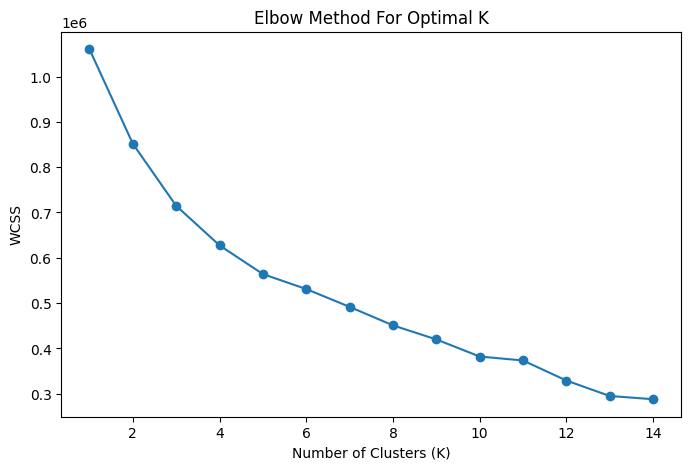

In [10]:
from sklearn.preprocessing import OneHotEncoder

features = ex_df[['goal','level','equipment']]

ohe = OneHotEncoder(handle_unknown='ignore')

encoded_features = ohe.fit_transform(features)

find_optimal_clusters(encoded_features)

In [66]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import random


# ---------------------------------
# Build Clustering Model
# ---------------------------------

def create_clustering_model(df,num_clusters):

    print("Building clustering model...")

    features = df[['goal', 'level', 'equipment']]

    ohe = OneHotEncoder(handle_unknown='ignore')

    encoded_features = ohe.fit_transform(features)




    kmeans = KMeans(
        n_clusters=num_clusters,
        random_state=42,
        n_init=10
    )

    kmeans.fit(encoded_features)

    df['cluster'] = kmeans.labels_

    print("Model built successfully.")

    return kmeans, ohe, encoded_features, df


# ---------------------------------
# Recommendation Function
# ---------------------------------

def recommend_workouts(user_goal,
                       user_level,
                       user_equipment,
                       kmeans_model,
                       ohe_encoder,
                       encoded_data,
                       df,
                       num_recommendations=5):

    print("\nGenerating recommendations...")

    # -------------------------
    # User Input
    # -------------------------

    user_input = pd.DataFrame(
        [[user_goal.lower(), user_level.lower(), user_equipment.lower()]],
        columns=['goal', 'level', 'equipment']
    )

    # -------------------------
    # Encoding
    # -------------------------

    user_encoded = ohe_encoder.transform(user_input)

    # -------------------------
    # Find Cluster
    # -------------------------

    user_cluster = kmeans_model.predict(user_encoded)[0]

    cluster_indices = df[df['cluster'] == user_cluster].index  ##rows for clusters

    if len(cluster_indices) == 0:
    # اختر أقرب cluster بالـ centroid
      distances = kmeans_model.transform(user_encoded)  # المسافة لكل cluster
      closest_cluster = np.argmin(distances)
      cluster_indices = df[df['cluster'] == closest_cluster].index

    # -------------------------
    # Similarity Calculation
    # -------------------------

    cluster_vectors = encoded_data[df.index.isin(cluster_indices)].toarray()
    user_encoded_dense = user_encoded.toarray()

    similarities = cosine_similarity(user_encoded_dense, cluster_vectors)[0]

    # -------------------------
    # Ranking
    # -------------------------

    cluster_df = df.loc[cluster_indices].copy()
    cluster_df['similarity'] = similarities
    cluster_df = cluster_df.drop_duplicates(subset='title', keep='first')

    recommendations = cluster_df.sort_values(
        by='similarity',
        ascending=False
    ).head(num_recommendations)

    print("Recommendations ready.")

    return recommendations

In [67]:
kmeans_model, ohe_encoder, encoded_data, df = create_clustering_model(ex_df,num_clusters=6)

Building clustering model...
Model built successfully.


In [68]:
cluster_counts = ex_df['cluster'].value_counts()

# Display the number of elements in each cluster
print("Number of elements in each cluster:")
print(cluster_counts)

Number of elements in each cluster:
cluster
3    170130
0    109554
2    101166
1     83503
5     71570
4     68275
Name: count, dtype: int64


In [76]:
recs = recommend_workouts(
    user_goal="bodybuilding",
    user_level="intermediate",
    user_equipment="full gym",
    kmeans_model=kmeans_model,
    ohe_encoder=ohe_encoder,
    encoded_data=encoded_data,
    df=ex_df,
    num_recommendations=7
)

def display_workout_plan(recommendations):
    print("\n===== Your Personalized Workout Plan =====\n")
    for idx, row in enumerate(recommendations.itertuples(), 1):  # 1-based index
        print(f"Workout {idx}: {row.title}")
        print(f"  - Goal      : {row.goal.capitalize()}")
        print(f"  - Level     : {row.level.capitalize()}")
        print(f"  - Equipment : {row.equipment.capitalize()}")
        print("-" * 40)

display_workout_plan(recs)


Generating recommendations...
Recommendations ready.

===== Your Personalized Workout Plan =====

Workout 1: Matt Vena modified
  - Goal      : Bodybuilding
  - Level     : Intermediate
  - Equipment : Full gym
----------------------------------------
Workout 2: Lyle McDonald Routine (Strength/Hypertrophy Vers)
  - Goal      : Bodybuilding
  - Level     : Intermediate
  - Equipment : Full gym
----------------------------------------
Workout 3: Jeff Nippard’s Fundamentals, Upper&Lower Split, 4x
  - Goal      : Bodybuilding
  - Level     : Intermediate
  - Equipment : Full gym
----------------------------------------
Workout 4: Strength and Lean muscle building ideal for Teens
  - Goal      : Bodybuilding
  - Level     : Intermediate
  - Equipment : Full gym
----------------------------------------
Workout 5: Rampage
  - Goal      : Bodybuilding
  - Level     : Intermediate
  - Equipment : Full gym
----------------------------------------
Workout 6: Fitness King Powerbuild 101
  - Goal 

In [80]:
import joblib
import os

# إنشاء المجلد لو مش موجود
models_dir = 'saved_model'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# حفظ الموديل والـ encoder والـ encoded data داخل المجلد
joblib.dump(kmeans_model, os.path.join(models_dir, 'kmeans_model_ex.pkl'))
joblib.dump(ohe_encoder, os.path.join(models_dir, 'ohe_encoder_ex.pkl'))
joblib.dump(encoded_data, os.path.join(models_dir, 'encoded_data_ex.pkl'))

print(f"✅ Model, encoder, and encoded data saved successfully in '{models_dir}' folder!")

✅ Model, encoder, and encoded data saved successfully in 'saved_model' folder!


In [ ]:
kmeans_model = joblib.load('saved_model/kmeans_model_ex.pkl')
ohe_encoder = joblib.load('saved_model/ohe_encoder_ex.pkl')
encoded_data = joblib.load('saved_model/encoded_data_ex.pkl')

In [178]:
app_code_ex ='''

import streamlit as st
import pandas as pd
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import ast

# =========================
# Load Saved Model & Data
# =========================
@st.cache_resource
def load_models():
    kmeans_model = joblib.load('saved_model/kmeans_model_ex.pkl')
    ohe_encoder = joblib.load('saved_model/ohe_encoder_ex.pkl')
    encoded_data = joblib.load('saved_model/encoded_data_ex.pkl')
    df = pd.read_csv('programs_detailed_boostcamp_kaggle.csv')
    return kmeans_model, ohe_encoder, encoded_data, df

kmeans_model, ohe_encoder, encoded_data, df = load_models()

# =========================
# Cleaning & Normalize
# =========================
def list_to_str(val):
    """تحويل أي قائمة أو نص شبه قائمة لنص مفصول بفواصل"""
    if isinstance(val, list):
        return ", ".join([str(v).strip() for v in val if v])
    elif isinstance(val, str) and val.startswith("[") and val.endswith("]"):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return ", ".join([str(v).strip() for v in parsed if v])
        except:
            pass
    return str(val).strip()

columns_to_clean = ['goal', 'level', 'equipment']
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].apply(list_to_str)
        df[col] = df[col].str.lower()

# حذف القيم المفقودة المهمة
df.dropna(subset=['goal', 'level', 'equipment', 'description'], inplace=True)

if df.empty:
    raise ValueError("DataFrame is empty after cleaning. Please check your data.")

# =========================
# Extract options for Streamlit
# =========================
goal_options = sorted([g.title() for g in pd.Series(",".join(df['goal'].unique()).split(",")).str.strip().unique() if g])
level_options = sorted([l.title() for l in pd.Series(",".join(df['level'].unique()).split(",")).str.strip().unique() if l])
equipment_options = sorted([e.title() for e in pd.Series(",".join(df['equipment'].unique()).split(",")).str.strip().unique() if e])

# =========================
# Recommendation Function
# =========================
def recommend_workouts(user_goal, user_level, user_equipment, num_recommendations=5):
    # تحويل الإدخال لحالة صغيرة
    user_goal = user_goal.lower()
    user_level = user_level.lower()
    user_equipment = user_equipment.lower()

    # فلترة دقيقة حسب اختيار المستخدم
    filtered_df = df[
        df['goal'].str.contains(user_goal, case=False, na=False) &
        df['level'].str.contains(user_level, case=False, na=False) &
        df['equipment'].str.contains(user_equipment, case=False, na=False)
    ].copy()

    if filtered_df.empty:
        # لو مفيش أي تمرين مطابق بالظبط، استخدم النموذج KMeans كاحتياط
        user_input = pd.DataFrame([[user_goal, user_level, user_equipment]], columns=['goal','level','equipment'])
        user_encoded = ohe_encoder.transform(user_input).toarray()
        cluster_labels = kmeans_model.predict(encoded_data)
        user_cluster = kmeans_model.predict(user_encoded)[0]
        cluster_indices = [i for i, label in enumerate(cluster_labels) if label == user_cluster]
        filtered_df = df.iloc[cluster_indices].copy()

    # حساب التشابه
    user_input_encoded = ohe_encoder.transform(pd.DataFrame([[user_goal, user_level, user_equipment]],
                                                            columns=['goal','level','equipment'])).toarray()
    cluster_vectors = ohe_encoder.transform(filtered_df[['goal','level','equipment']]).toarray()
    similarities = cosine_similarity(user_input_encoded, cluster_vectors)[0]
    filtered_df['similarity'] = similarities

    return filtered_df.sort_values(by='similarity', ascending=False).head(num_recommendations)
# =========================
# Streamlit UI
# =========================
st.title("🏋️ Personalized Workout Planner")
st.sidebar.header("Your Preferences")

goal = st.sidebar.selectbox("Select Your Goal:", goal_options)
level = st.sidebar.selectbox("Select Your Level:", level_options)
equipment = st.sidebar.selectbox("Select Available Equipment:", equipment_options)
num_rec = st.sidebar.slider("Number of Recommendations:", 1, 10, 5)

if st.sidebar.button("Generate Plan"):
    recs = recommend_workouts(goal, level, equipment, num_rec)
    st.subheader("✅ Your Personalized Workout Plan")
    for idx, row in enumerate(recs.itertuples(), 1):
        st.markdown(f"**Workout {idx}: {row.title}**")
        st.markdown(f"- Goal      : {', '.join([g.strip().title() for g in row.goal.split(',')])}")
        st.markdown(f"- Level     : {', '.join([l.strip().title() for l in row.level.split(',')])}")
        st.markdown(f"- Equipment : {', '.join([e.strip().title() for e in row.equipment.split(',')])}")
        st.markdown("---")
'''
with open("app.py2", "w") as f:
    f.write(app_code_ex)
print("✅ Streamlit app2 saved as app.py with exercise")

✅ Streamlit app2 saved as app.py with exercise
